In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sci

In [7]:
x = np.linspace(0.0, 2.0 * np.pi, 100)

In [49]:
def exponential(x, a=4.0, b=-0.4):
    '''
    inputs:
        x - an array of floating points
        a - exponent base
        b - exponent coefficient
    return:
        y - an array of floating points taken from performing an operation on each value of x
    '''
    y = []
    for i in x:
        value = a**(-b * i)
        y.append(value)

    return np.array(y)

In [50]:
def sigma():
    '''
    inputs:
        none
    return:
        s - an array of 100 values slowly decreasing
    '''
    s = []
    for i in np.linspace(2.0,0.2,100):
        s.append(np.random.normal(i,0.1))
    return np.asarray(s)

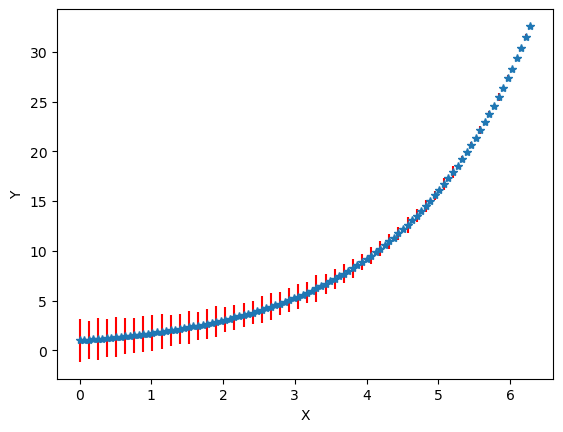

In [51]:
#plt.plot(x,exponential(x), c='k', zorder = 0)
plt.errorbar(x,exponential(x),yerr=sigma(),ecolor='r',fmt = '*',errorevery=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.savefig("error.pdf", format ="pdf")

In [52]:
yClean = exponential(x)
yDirty = yClean + sigma()

In [53]:
def modelExpo(x,a,b):
    yModel = a**(-b*x)
    return yModel
def modelDivis(x,a,b):
    yModel = a / (x**b)
    return yModel

In [54]:
def leastSquares(xData, yData, model, p0, nSteps = 499, jumpSig = 0.1):
    '''
    inputs:
        xData: 1d array_like, giving x-coordinates of dataset to be fitted
        yData: 1d array_like, giving y-coordinates of dataset to be fitted
        model: python function, gives model to use on fit
        p0: array-like giving initial guess for the model
        nSteps (optional): int, number of steps for random walker. Default is 500
        jumpSig (optional): array-like, standard deviation to be used in random jump

    returns:
        walk: nd-array of shape (nsteps+1,len(p0)) random walk where each step
            improves the fit from the last one
        Ss: 1d-array of len(nSteps) + 1, gives the value of S for each step
    '''
   
    #setting an array filled with zeroes which will be our final answer: each step of the walk
    #the array has nsteps+1 rows because the first row should be the initial guess!
    walk = np.zeros(shape=(nSteps + 1, len(p0)))

    #setting the first position of the walker to be the initial position
    walk[0,:] = p0

    #setting an empty array for values of S
    Ss = []

    #first value of S is the one from the initial guess
    Ss.append(calculateS(yData,model(xData,*p0)))

    #use a while loop since this is gonna take a while
    i = 0
    while len(Ss) < nSteps + 1:
        #grab latest position of the walker
        previousPosition = walk[i,:]

        #making the jump be a gaussian with standard deviation sigma and mean of 0
        #the size should be len(p0) such that the variable jump can be applied to each coordinate at once
        jump = np.random.normal(scale = jumpSig, size = len(p0))

        #applying the jump to previousPosition, getting the new position of the walker
        newPosition = previousPosition + jump

        #calculate S after jump
        sLoop =  calculateS(yData,model(xData,*newPosition))
        
        #if this S is smaller than the previous one, save it
        if sLoop <= Ss[i]:
            #save the new value of S in the list, increasing the len of S by another step
            Ss.append(sLoop)
            
            #saving the new position into our return array
            walk[i+1,:] = newPosition

            #iterate
            i+=1
        elif np.random.random() < np.exp(Ss[i] - sLoop):
            #save the new value of S in the list, increasing the len of S by another step
            Ss.append(sLoop)
            
            #saving the new position into our return array
            walk[i+1,:] = newPosition

            #iterate
            i+=1
        else:
            continue
    
    #once the loop is over, return the walk to the user
    #Since we originally defined S as a python list, transform it to a numpy array
    return walk, np.asarray(Ss)

In [55]:
def calculateS(yData, yModel):
    '''
    inputs:
        yData: 1d array_like, data points to fit model into
        yModel: 1d array_like with same length as yData. Model to compare against data

    return:
        S: sum of the residuals squared between models and data
    '''

    #calculate the residuals
    residuals = yData - yModel

    S = np.sum(residuals**2)
    return S

In [56]:
walkExampleExpo, sExampleExpo = leastSquares(x,yDirty, modelExpo, p0=[1,0])
walkExampleDivis, sExampleDivis = leastSquares(x,yDirty, modelDivis, p0=[2,20])

C:\Users\mimi\AppData\Local\Temp\ipykernel_20956\3445608522.py:5: RuntimeWarning: divide by zero encountered in divide
  yModel = a / (x**b)


In [57]:
aWalkExpo = walkExampleExpo[:,0]
bWalkExpo = walkExampleExpo[:,1]

Text(0, 0.5, 'b')

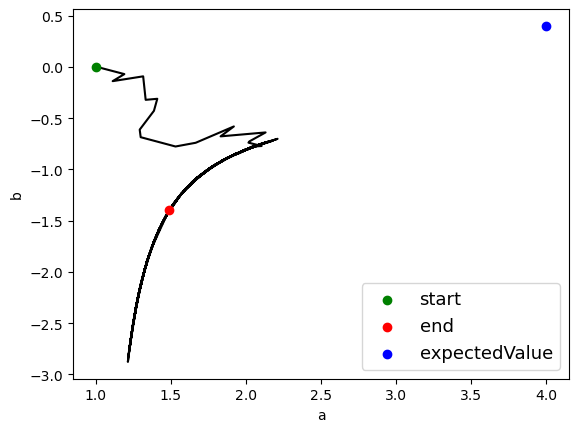

In [61]:
plt.plot(aWalkExpo,bWalkExpo, 'k', zorder = 0)
plt.scatter(aWalkExpo[0], bWalkExpo[0], c='g', label = 'start', zorder = 2)
plt.scatter(aWalkExpo[-1], bWalkExpo[-1], c='r', label = 'end', zorder = 3)
plt.legend(fontsize = 13)
plt.xlabel('a')
plt.ylabel('b')

C:\Users\mimi\AppData\Local\Temp\ipykernel_20956\3445608522.py:5: RuntimeWarning: divide by zero encountered in power
  yModel = a / (x**b)
C:\Users\mimi\AppData\Local\Temp\ipykernel_20956\3976307476.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Y')

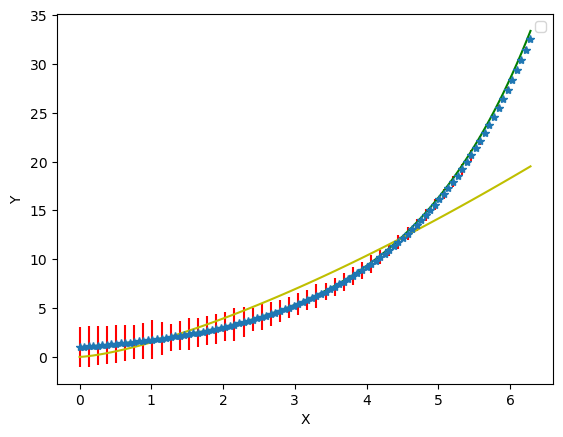

In [76]:
plt.errorbar(x,exponential(x),yerr=sigma(),ecolor='r',fmt = '*',errorevery=2)
plt.plot(x,modelExpo(x,a=aWalkExpo[-1], b=bWalkExpo[-1]),c='g',)
plt.plot(x,modelDivis(x,a=aWalkExpo[-1], b=bWalkExpo[-1]),c='y')
plt.xlabel('X')
plt.ylabel('Y')

C:\Users\mimi\AppData\Local\Temp\ipykernel_20956\3445608522.py:5: RuntimeWarning: divide by zero encountered in power
  yModel = a / (x**b)


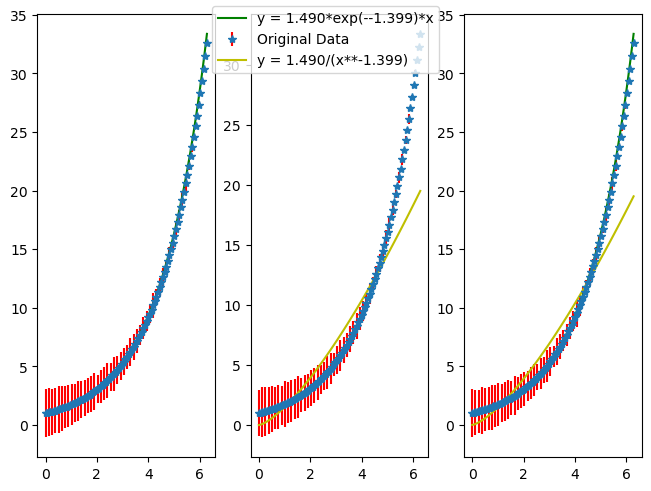

<Figure size 640x480 with 0 Axes>

In [98]:
fig, axis = plt.subplots(1,3,layout = 'constrained')
axis[0].errorbar(x,exponential(x),yerr=sigma(),ecolor='r',fmt = '*',errorevery=2,label="Original Data")
axis[1].errorbar(x,exponential(x),yerr=sigma(),ecolor='r',fmt = '*',errorevery=2)
axis[2].errorbar(x,exponential(x),yerr=sigma(),ecolor='r',fmt = '*',errorevery=2)

axis[0].plot(x,modelExpo(x,a=aWalkExpo[-1], b=bWalkExpo[-1]),c='g',label=f"y = {aWalkExpo[-1]:0.3f}*exp(-{bWalkExpo[-1]:0.3f})*x")
axis[2].plot(x,modelExpo(x,a=aWalkExpo[-1], b=bWalkExpo[-1]),c='g')

axis[1].plot(x,modelDivis(x,a=aWalkExpo[-1], b=bWalkExpo[-1]),c='y',label=f"y = {aWalkExpo[-1]:0.3f}/(x**{bWalkExpo[-1]:0.3f})")
axis[2].plot(x,modelDivis(x,a=aWalkExpo[-1], b=bWalkExpo[-1]),c='y')
fig.legend(loc='upper center')

plt.show()
plt.savefig("comparison.pdf", format ="pdf")